In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
import seaborn as sns
from sklearn.metrics import (mean_squared_error, mean_absolute_error, 
                            r2_score, explained_variance_score)
from yellowbrick.regressor import (residuals_plot, prediction_error)
import shap
from sklearn.base import clone
from scipy import stats
import joblib
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [33]:
model = joblib.load("../../../../models/bayesian_ridge/bayesian_ridge_model_label_v1.joblib")

In [34]:
df = pd.read_csv('../../../../data/preprocessed/selected_features_dataset_V2.csv')

X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
X_train_main, X_val, y_train_main, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [36]:
df.head()

,address_locality,address_line_2,near_Koh_Pich_in_km,near_Bassac_Lane_in_km,near_Royal_Palace_in_km,near_Phnom_Penh_Airport_in_km,n_secondary_school_in_3km_to_5km,n_primary_school_5km,n_primary_school_in_3km_to_5km,n_university_in_2km_to_3km,n_university_in_3km_to_5km,n_resturant_in_1km,n_super_market_5km,n_super_market_in_1km_to_2km,n_bank_5km,price_per_m2
0,5.00,78.00,5.75,4.00,5.06,3.94,48.00,92.00,47.00,47.00,31.00,0.00,80.00,8.00,148.00,3249.77
1,0.00,48.00,2.95,2.22,3.80,7.98,38.00,62.00,37.00,10.00,45.00,0.00,78.00,8.00,158.00,2357.96
2,10.00,45.00,6.82,4.93,4.77,6.13,41.00,69.00,45.00,40.00,36.00,1.00,69.00,11.00,160.00,3466.33
3,10.00,45.00,6.08,4.15,3.88,5.95,44.00,83.00,45.00,18.00,34.00,1.00,92.00,9.00,161.00,2979.37
4,4.00,14.00,0.81,2.92,2.75,13.11,29.00,25.00,23.00,3.00,20.00,0.00,64.00,0.00,105.00,5133.65


In [37]:
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    explained_variance_score, mean_absolute_percentage_error
)
import numpy as np
import pandas as pd

def calculate_metrics(model, X_train, X_test, y_train, y_test):
    """Calculate regression metrics including MAPE and average prices (actual & predicted)"""
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    metrics = {
        'Train R²': r2_score(y_train, y_pred_train),
        'Test R²': r2_score(y_test, y_pred_test),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'Train MAE': mean_absolute_error(y_train, y_pred_train),
        'Test MAE': mean_absolute_error(y_test, y_pred_test),
        'Train MAPE (%)': mean_absolute_percentage_error(y_train, y_pred_train) * 100,
        'Test MAPE (%)': mean_absolute_percentage_error(y_test, y_pred_test) * 100,
        'Explained Variance': explained_variance_score(y_test, y_pred_test),
        'Train-Test R² Gap': abs(r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred_test)),
        'Avg Actual Train Price': np.mean(y_train),
        'Avg Predicted Train Price': np.mean(y_pred_train),
        'Avg Actual Test Price': np.mean(y_test),
        'Avg Predicted Test Price': np.mean(y_pred_test)
    }
    
    return pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])

# Usage
metrics_df = calculate_metrics(model, X_train, X_test, y_train, y_test)
print(metrics_df)

                            Value
Train R²                     0.86
Test R²                      0.85
Train RMSE                 676.20
Test RMSE                  675.04
Train MAE                  426.61
Test MAE                   438.84
Train MAPE (%)              72.58
Test MAPE (%)               73.20
Explained Variance           0.85
Train-Test R² Gap            0.01
Avg Actual Train Price    1585.36
Avg Predicted Train Price 1585.36
Avg Actual Test Price     1596.47
Avg Predicted Test Price  1631.58


In [38]:
def evaluate_by_decoded_location(model, X_test, y_test, location_col='address_line_2', min_samples=3):
    """
    Evaluate model performance with decoded location names using provided encoding maps
    
    Parameters:
    model : Trained model
    X_test : Test features
    y_test : True target values
    location_col : Column name containing encoded location codes
    min_samples : Minimum samples required to evaluate a location
    
    Returns:
    DataFrame with metrics for each decoded location
    """
    # Your provided encoding maps
    encoding_maps = {
        'address_line_2': {
            'Bak Kaeng': 0, 'Boeng Kak Ti Muoy': 1, 'Boeng Kak Ti Pir': 2, 
            'Boeng Keng Kang Ti Bei': 3, 'Boeng Keng Kang Ti Muoy': 4, 
            'Boeng Keng Kang Ti Pir': 5, 'Boeng Proluet': 6, 'Boeng Reang': 7,
            'Boeng Salang': 8, 'Boeng Thum': 9, 'Boeng Trabaek': 10,
            'Boeng Tumpun': 11, 'Chak Angrae Kraom': 12, 'Chak Angrae Leu': 13,
            'Chakto Mukh': 14, 'Chaom Chau': 15, 'Chbar Ampov Ti Pir': 16,
            'Cheung Aek': 17, 'Chey Chummeah': 18, 'Chhbar Ampov Ti Muoy': 19,
            'Chrang Chamreh Ti Muoy': 20, 'Chrang Chamreh Ti Pir': 21,
            'Chrouy Changvar': 22, 'Dangkao': 23, 'Kakab': 24, 'Kamboul': 25,
            'Kantaok': 26, 'Kaoh Dach': 27, 'Kbal Kaoh': 28, 'Khmuonh': 29,
            'Kilomaetr Lekh Prammuoy': 30, 'Kong Noy': 31, 'Kouk Roka': 32,
            'Krang Pongro': 33, 'Krang Thnong': 34, 'Mittapheap': 35,
            'Monourom': 36, 'Nirouth': 37, 'Olympic': 38, 'Ou Ruessei Ti Bei': 39,
            'Ou Ruessei Ti Buon': 40, 'Ou Ruessei Ti Muoy': 41, 'Ou Ruessei Ti Pir': 42,
            'Ovlaok': 43, 'Phleung Chheh Roteh': 44, 'Phnom Penh Thmei': 45,
            'Phsar Chas': 46, 'Phsar Daeum Kor': 47, 'Phsar Daeum Thkov': 48,
            'Phsar Depou Ti Bei': 49, 'Phsar Depou Ti Muoy': 50, 'Phsar Depou Ti Pir': 51,
            'Phsar Kandal Ti Muoy': 52, 'Phsar Kandal Ti Pir': 53, 'Phsar Thmei Ti Bei': 54,
            'Phsar Thmei Ti Muoy': 55, 'Phsar Thmei Ti Pir': 56, 'Pong Tuek': 57,
            'Ponhea Pon': 58, 'Ponsang': 59, 'Prateah Lang': 60, 'Preaek Aeng': 61,
            'Preaek Kampues': 62, 'Preaek Lieb': 63, 'Preaek Phnov': 64, 'Preaek Pra': 65,
            'Preaek Ta Sek': 66, 'Preaek Thmei': 67, 'Prey Sa': 68, 'Prey Veaeng': 69,
            'Roluos': 70, 'Ruessei Kaev': 71, 'Sak Sampov': 72, 'Samraong': 73,
            'Samraong Kraom': 74, 'Snaor': 75, 'Spean Thma': 76, 'Srah Chak': 77,
            'Stueng Mean Chey': 78, 'Svay Pak': 79, 'Tien': 80, 'Tonle Basak': 81,
            'Trapeang Krasang': 82, "Tuek L'ak Ti Bei": 83, "Tuek L'ak Ti Muoy": 84,
            "Tuek L'ak Ti Pir": 85, 'Tuek Thla': 86, 'Tumnob Tuek': 87,
            'Tuol Sangke': 88, 'Tuol Svay Prey Ti Muoy': 89, 'Tuol Svay Prey Ti Pir': 90,
            'Tuol Tumpung Ti Muoy': 91, 'Tuol Tumpung Ti Pir': 92, 'Veal Sbov': 93,
            'Veal Vong': 94, 'Voat Phnum': 95
        }
    }
    
    # Create reverse mapping (code to name)
    reverse_map = {v: k for k, v in encoding_maps[location_col].items()}
    
    # Create a copy of the data
    X_test_copy = X_test.copy()
    X_test_copy['price_per_m2'] = y_test.values
    
    results = []
    locations = X_test_copy[location_col].unique()
    
    for loc in locations:
        loc_data = X_test_copy[X_test_copy[location_col] == loc]
        
        if len(loc_data) < min_samples:
            continue
            
        # Keep all original features (don't drop location_col)
        X_loc = loc_data.drop(['price_per_m2'], axis=1)
        y_loc = loc_data['price_per_m2']
        y_pred = model.predict(X_loc)
        
        # Decode the location name
        location_name = reverse_map.get(loc, f"Unknown (Code: {loc})")
        
        results.append({
            'Location Code': loc,
            'Location Name': location_name,
            'Samples': len(loc_data),
            'RMSE': np.sqrt(mean_squared_error(y_loc, y_pred)),
            'MAE': mean_absolute_error(y_loc, y_pred),
            'R²': r2_score(y_loc, y_pred),
            'Avg Actual Price': y_loc.mean(),
            'Avg Predicted Price': y_pred.mean(),
            'Price Difference': y_loc.mean() - y_pred.mean(),
            '% Difference': ((y_loc.mean() - y_pred.mean()) / y_loc.mean()) * 100
        })
    
    # Create and format DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Samples', ascending=False)
    
    # Format numeric columns
    float_cols = ['RMSE', 'MAE', 'R²', 'Avg Actual Price', 
                 'Avg Predicted Price', 'Price Difference', '% Difference']
    results_df[float_cols] = results_df[float_cols].round(2)
    
    # Set display options
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.float_format', '{:.2f}'.format)
    
    return results_df

# Example usage
location_metrics = evaluate_by_decoded_location(
    model, 
    X_test, 
    y_test,
    location_col='address_line_2'
)

# Display the results
print("Model Performance by Decoded Location:")
display(location_metrics)  # Show top 20 locations by sample size

Model Performance by Decoded Location:


,Location Code,Location Name,Samples,RMSE,MAE,R²,Avg Actual Price,Avg Predicted Price,Price Difference,% Difference
24,15.00,Chaom Chau,61,492.10,393.10,0.24,1568.93,1484.99,83.94,5.35
4,59.00,Ponsang,59,102.49,83.31,-3.02,140.83,163.32,-22.49,-15.97
19,28.00,Kbal Kaoh,52,177.46,148.21,0.20,330.30,433.27,-102.97,-31.17
61,78.00,Stueng Mean Chey,49,705.20,570.72,-1.01,3119.38,2833.18,286.20,9.17
28,45.00,Phnom Penh Thmei,48,794.65,665.97,-3.35,2958.78,2553.35,405.43,13.70
...,...,...,...,...,...,...,...,...,...,...
81,85.00,Tuek L'ak Ti Pir,4,763.72,725.71,-10.50,2447.62,3173.33,-725.71,-29.65
82,38.00,Olympic,4,1050.46,849.40,-0.26,4857.76,4921.66,-63.90,-1.32
15,50.00,Phsar Depou Ti Muoy,4,729.91,637.46,-4.68,2599.92,3204.31,-604.39,-23.25
69,49.00,Phsar Depou Ti Bei,3,643.99,592.54,-234.35,3860.43,3267.88,592.54,15.35


In [39]:
import pandas as pd
import joblib
import numpy as np

# Load the data
X_encoded = X_test.copy()

# Load label encoders
label_encoders = joblib.load("../../../../data/processed/label_encoders_v2.pkl")

# Decode only 'address_line_2'
col = 'address_line_2'

if col in label_encoders:
    le = label_encoders[col]
    
    # Handle missing values and float-to-int safely
    if X_encoded[col].isnull().any():
        # Temporarily fill NaNs with a placeholder
        temp_col = X_encoded[col].copy()
        mask = temp_col.isnull()
        temp_col[~mask] = temp_col[~mask].astype(int)
        temp_col[mask] = -1  # dummy value, must be outside valid label range

        # Create an inverse map
        inverse_map = {v: k for k, v in zip(le.classes_, le.transform(le.classes_))}
        temp_col = temp_col.astype(int).map(inverse_map)
        temp_col[mask] = np.nan  # restore NaNs

        X_encoded[col] = temp_col
    else:
        # No NaNs: just cast to int and decode
        X_encoded[col] = le.inverse_transform(X_encoded[col].astype(int))
else:
    print(f"Encoder for column '{col}' not found.")


In [40]:
for col, le in label_encoders.items():
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\nEncoding map for column '{col}':")
    for k, v in mapping.items():
        print(f"  {k!r} -> {v}")


Encoding map for column 'address_subdivision':
  'Phnom Penh' -> 0

Encoding map for column 'address_locality':
  'Chamkar Mon' -> 0
  'Chbar Ampov' -> 1
  'Chraoy Chongvar' -> 2
  'Dangkao' -> 3
  'Doun Penh' -> 4
  'Mean Chey' -> 5
  'Praek Pnov' -> 6
  'Prampir Meakkakra' -> 7
  'Pur SenChey' -> 8
  'Russey Keo' -> 9
  'Saensokh' -> 10
  'Tuol Kouk' -> 11

Encoding map for column 'address_line_2':
  'Bak Kaeng' -> 0
  'Boeng Kak Ti Muoy' -> 1
  'Boeng Kak Ti Pir' -> 2
  'Boeng Keng Kang Ti Bei' -> 3
  'Boeng Keng Kang Ti Muoy' -> 4
  'Boeng Keng Kang Ti Pir' -> 5
  'Boeng Proluet' -> 6
  'Boeng Reang' -> 7
  'Boeng Salang' -> 8
  'Boeng Thum' -> 9
  'Boeng Trabaek' -> 10
  'Boeng Tumpun' -> 11
  'Chak Angrae Kraom' -> 12
  'Chak Angrae Leu' -> 13
  'Chakto Mukh' -> 14
  'Chaom Chau' -> 15
  'Chbar Ampov Ti Pir' -> 16
  'Cheung Aek' -> 17
  'Chey Chummeah' -> 18
  'Chhbar Ampov Ti Muoy' -> 19
  'Chrang Chamreh Ti Muoy' -> 20
  'Chrang Chamreh Ti Pir' -> 21
  'Chrouy Changvar' -> 22


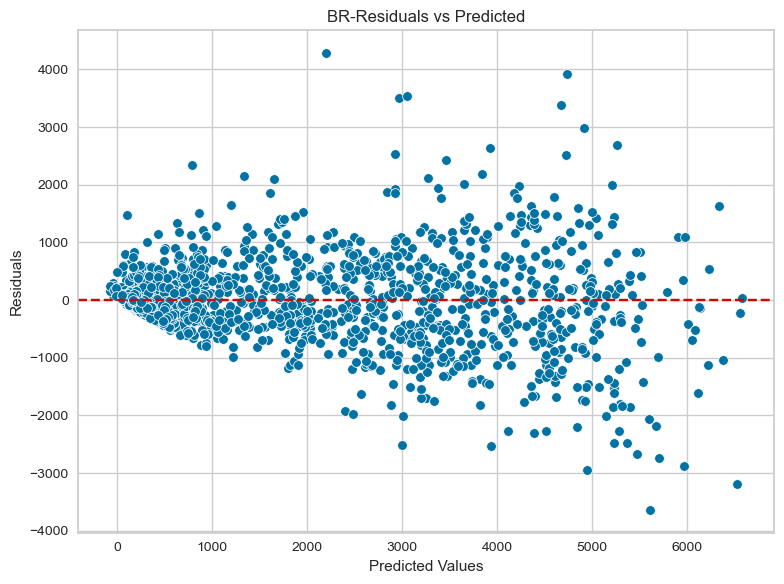

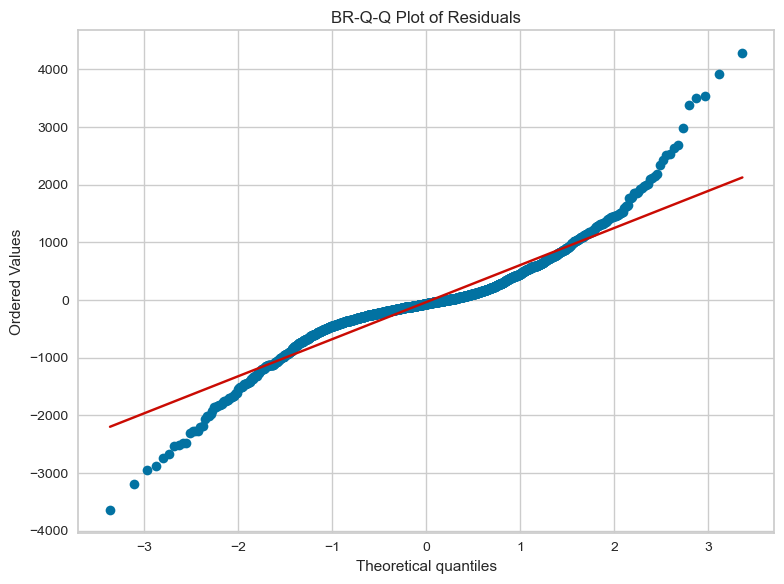

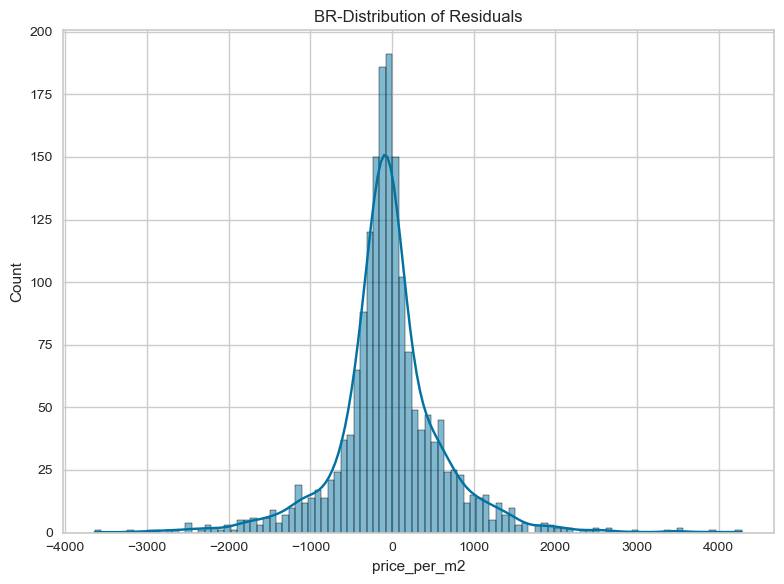

In [41]:
def plot_residuals_one_by_one(model, X_train, X_test, y_train, y_test):
    """Generate residual diagnostic plots"""
    y_pred_test = model.predict(X_test)
    residuals = y_test - y_pred_test

    # Residuals vs Predicted
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_pred_test, y=residuals)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('BR-Residuals vs Predicted')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.tight_layout()
    plt.show()

    # Q-Q Plot
    plt.figure(figsize=(8, 6))
    stats.probplot(residuals, plot=plt)
    plt.title('BR-Q-Q Plot of Residuals')
    plt.tight_layout()
    plt.show()

    # Residual Distribution
    plt.figure(figsize=(8, 6))
    sns.histplot(residuals, kde=True)
    plt.title('BR-Distribution of Residuals')
    plt.tight_layout()
    plt.show()

plot_residuals_one_by_one(model, X_train, X_test, y_train, y_test)

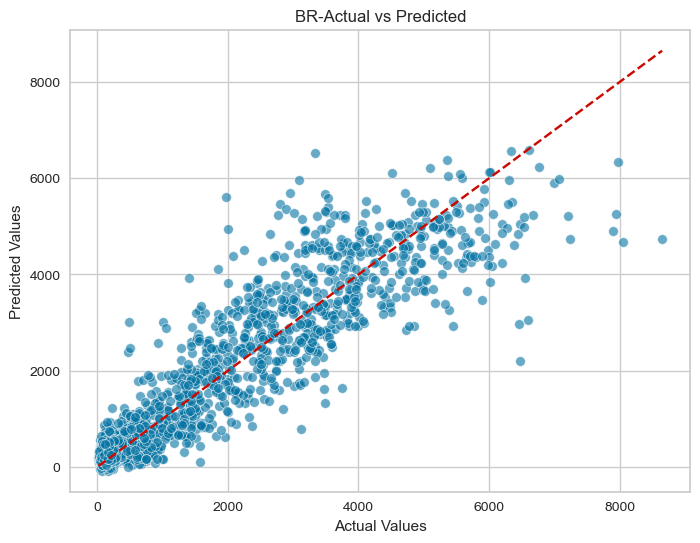

In [42]:
def plot_actual_vs_predicted(y_true, y_pred):
    """Scatter plot of actual vs predicted values"""
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], 
             [y_true.min(), y_true.max()], 'r--')
    plt.title('BR-Actual vs Predicted')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)
    plt.show()

y_pred_test = model.predict(X_test)
plot_actual_vs_predicted(y_test, y_pred_test)

In [43]:
# def plot_shap_summary(model, X, sample_size=100):
#     """Generate SHAP summary plot"""
#     X_sample = X.sample(sample_size, random_state=42)
    
#     # For BayesianRidge with polynomial features, we need to transform first
#     poly_features = model.named_steps['poly'].get_feature_names_out(X.columns)
#     X_sample_transformed = model.named_steps['poly'].transform(X_sample)
    
#     # Create explainer
#     explainer = shap.Explainer(model.named_steps['model'].predict, X_sample_transformed, feature_names=poly_features)
#     shap_values = explainer(X_sample_transformed)
    
#     # Summary plot (bar)
#     plt.figure()
#     shap.plots.bar(shap_values, max_display=20)
#     plt.tight_layout()
#     plt.show()
    
#     # Summary plot
#     plt.figure()
#     shap.summary_plot(shap_values.values, X_sample_transformed, feature_names=poly_features, max_display=20)
#     plt.tight_layout()
#     plt.show()

# plot_shap_summary(model, X_test)

d:\anaconda\envs\env_v3.10\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


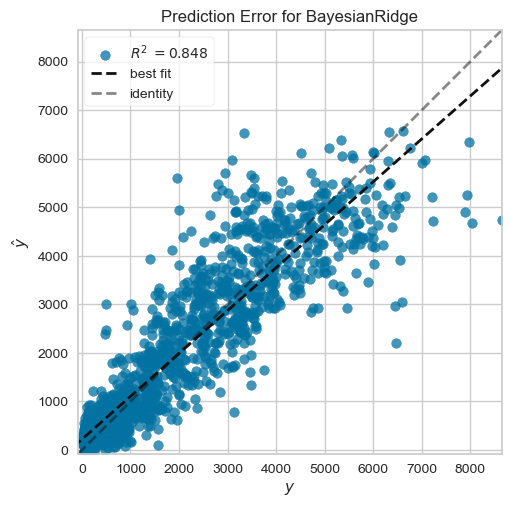

In [44]:
def plot_prediction_error(model, X_train, y_train, X_test, y_test):
    """Visualize prediction error with 45-degree line"""
    visualizer = prediction_error(
        model, X_train, y_train, X_test, y_test,
        bestfit=True, identity=True
    )
    visualizer.show()

plot_prediction_error(model, X_train, y_train, X_test, y_test)

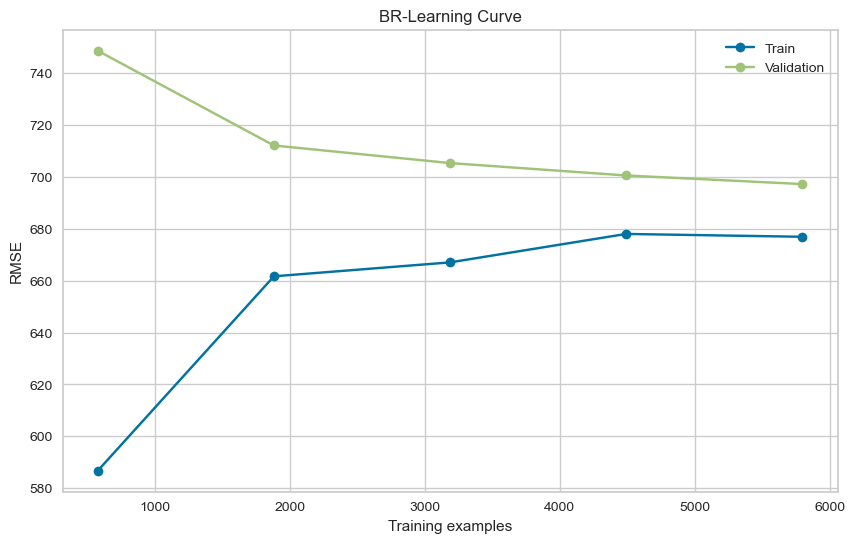

In [45]:
def plot_learning_curve(estimator, X, y):
    """Plot learning curve showing training and validation scores"""
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='neg_root_mean_squared_error'
    )
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, -train_scores.mean(1), 'o-', label='Train')
    plt.plot(train_sizes, -test_scores.mean(1), 'o-', label='Validation')
    plt.xlabel('Training examples')
    plt.ylabel('RMSE')
    plt.title('BR-Learning Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curve(model, X_train, y_train)

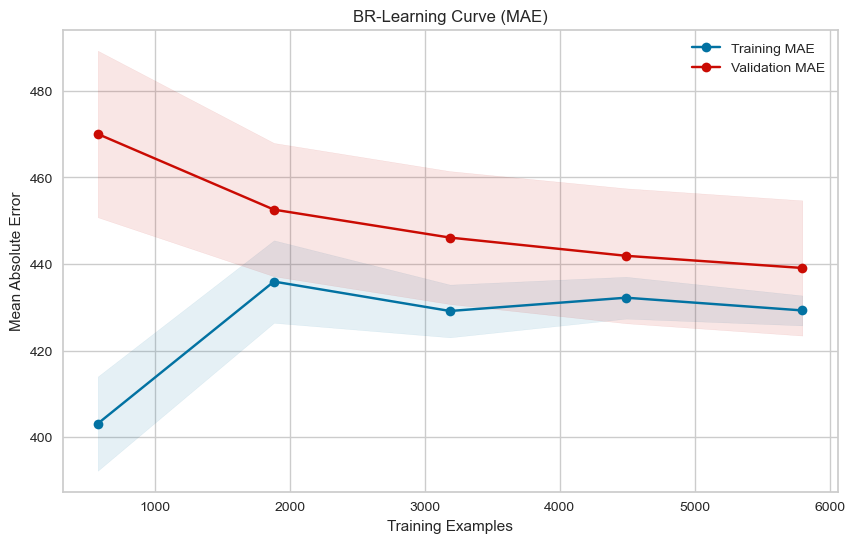

In [46]:
def plot_mae_learning_curve(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    """Generate MAE-based learning curve"""
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        n_jobs=-1,
        train_sizes=train_sizes,
        scoring='neg_mean_absolute_error'
    )
    
    train_mae = -train_scores
    val_mae = -val_scores
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mae.mean(axis=1), 'o-', color='b', label='Training MAE')
    plt.plot(train_sizes, val_mae.mean(axis=1), 'o-', color='r', label='Validation MAE')
    
    plt.title('BR-Learning Curve (MAE)')
    plt.xlabel('Training Examples')
    plt.ylabel('Mean Absolute Error')
    plt.legend()
    plt.grid(True)
    
    plt.fill_between(train_sizes, 
                    train_mae.mean(axis=1) - train_mae.std(axis=1),
                    train_mae.mean(axis=1) + train_mae.std(axis=1),
                    alpha=0.1, color='b')
    
    plt.fill_between(train_sizes,
                    val_mae.mean(axis=1) - val_mae.std(axis=1),
                    val_mae.mean(axis=1) + val_mae.std(axis=1),
                    alpha=0.1, color='r')
    
    plt.show()

plot_mae_learning_curve(model, X_train, y_train)

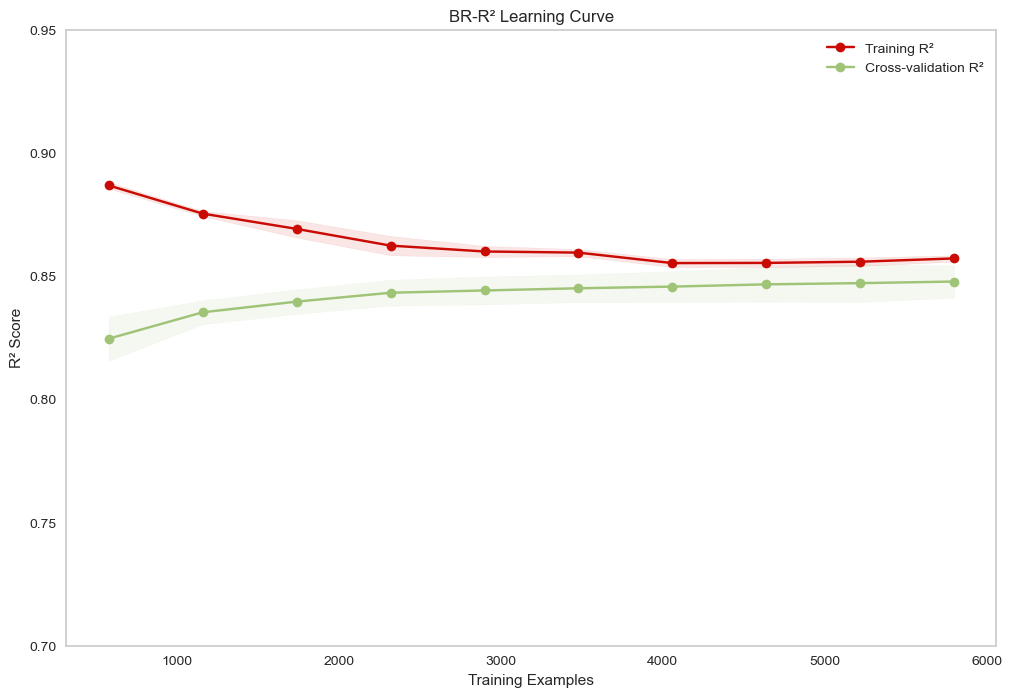

In [49]:
def plot_r2_learning_curve(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    """Generate R² learning curve with confidence intervals"""
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        n_jobs=-1,
        train_sizes=train_sizes,
        scoring='r2'
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(12, 8))
    plt.title("BR-R² Learning Curve")
    plt.xlabel("Training Examples")
    plt.ylabel("R² Score")
    plt.ylim(0.7, 0.95)
    
    plt.fill_between(train_sizes, 
                    train_scores_mean - train_scores_std,
                    train_scores_mean + train_scores_std,
                    alpha=0.1, color="r")
    plt.fill_between(train_sizes, 
                    test_scores_mean - test_scores_std,
                    test_scores_mean + test_scores_std,
                    alpha=0.1, color="g")
    
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training R²")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation R²")
    
    plt.legend(loc="best")
    plt.grid()
    plt.show()

plot_r2_learning_curve(model, X_train, y_train)